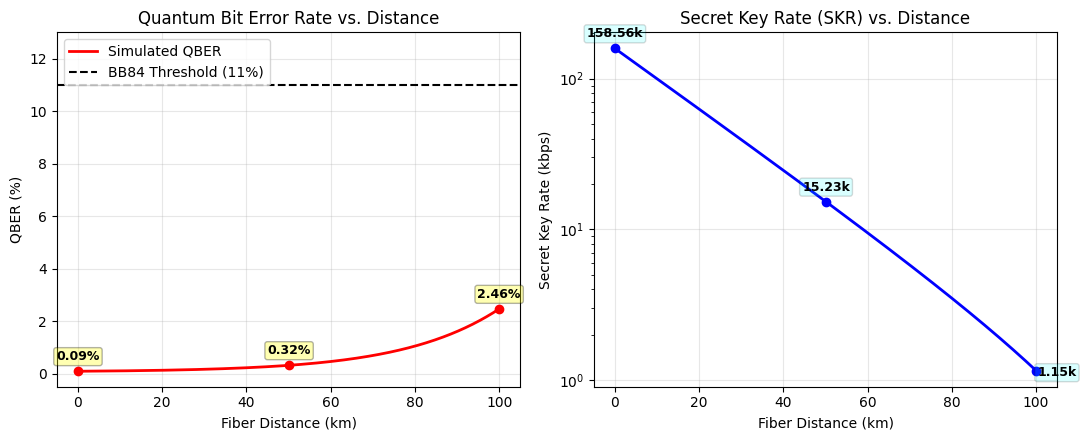

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# PIC PARAMETERS (From ONA & Characterization)
# ==========================================
IL_tx_dB = 5.56          # Alice Transmitter Insertion Loss (dB)
IL_rx_dB = 4.48          # Bob Receiver Insertion Loss (dB)
ER_dB = 37.0             # Worst-case Rectilinear Extinction Ratio (dB)
pol_error_deg = 1.2      # Corrected: Polarization Angle Error in degrees

# Convert to linear scale
eta_tx = 10**(-IL_tx_dB / 10.0)   
eta_rx = 10**(-IL_rx_dB / 10.0)   
er_linear = 10**(ER_dB / 10.0)    

# Corrected alignment error formula for pure polarization rotation
e_opt = (1.0 / (1.0 + er_linear)) + np.sin(pol_error_deg / 180.0 * np.pi)**2 

# ==========================================
# QUANTUM CHANNEL & DETECTOR PARAMETERS
# ==========================================
f_rep = 100e6            # Pulse rate clock (100 MHz)
mu = 0.2                 # Weak Coherent Pulse intensity (photon/pulse)
alpha = 0.2              # Fiber loss at 1550 nm (0.2 dB/km)

# Single-Photon Avalanche Diode (SPAD) Specifications (InGaAs)
eta_d = 0.20             # Detector Quantum Efficiency (20%)
p_dark = 1e-6            # Dark count probability per gate/pulse (per detector)
f_EC = 1.16              # Error correction efficiency factor

# ==========================================
# DISTANCE & SECRET KEY RATE CALCULATION
# ==========================================
L = np.linspace(0, 100, 400)       # Distance vector from 0 to 100 km
eta_ch = 10**(-alpha * L / 10.0)   # Fiber channel transmittance

# System efficiency excluding detector dark counts
eta_sys = eta_tx * eta_ch * eta_rx * eta_d 

# Corrected Total Gain (Detection probability per pulse)
Q_mu = mu * eta_sys + 2 * p_dark

# Corrected Total System QBER
QBER = (e_opt * mu * eta_sys + 0.5 * (2 * p_dark)) / Q_mu

# Binary Shannon Entropy Function
def binary_entropy(e):
    e = np.clip(e, 1e-12, 0.5 - 1e-12)
    return -e * np.log2(e) - (1 - e) * np.log2(1 - e)

# Corrected Single-Photon Parameters (GLLP Framework for WCP)
Y1 = eta_sys + 2 * p_dark
Q1 = (mu * np.exp(-mu)) * Y1
e1 = (e_opt * eta_sys + 0.5 * (2 * p_dark)) / Y1

# Asymptotic Secret Key Rate (SKR) in bits/second (with 0.5 sifting factor)
sifting_efficiency = 0.5
SKR = f_rep * sifting_efficiency * (Q1 * (1 - binary_entropy(e1)) - Q_mu * f_EC * binary_entropy(QBER))
SKR = np.maximum(SKR, 0) # Non-negative key rate

# ==========================================
# ANNOTATION EXTRACTION POINTS (0, 50, 100 km)
# ==========================================
target_distances = [0, 50, 100]
annot_indices = [np.abs(L - d).argmin() for d in target_distances]

# ==========================================
# PLOTTING THE RESULTS WITH DATA POINTS
# ==========================================
plt.figure(figsize=(11, 4.5))

# Subplot 1: QBER vs Distance
plt.subplot(1, 2, 1)
plt.plot(L, QBER * 100, 'r-', linewidth=2, label='Simulated QBER')
plt.axhline(y=11, color='k', linestyle='--', label='BB84 Threshold (11%)')

# Plot and annotate specific points on QBER
for idx in annot_indices:
    dist = L[idx]
    val = QBER[idx] * 100
    plt.plot(dist, val, 'ro')  # Add a red marker point
    plt.annotate(f"{val:.2f}%", (dist, val), textcoords="offset points", 
                 xytext=(0, 8), ha='center', fontsize=9, fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.3))

plt.xlabel('Fiber Distance (km)')
plt.ylabel('QBER (%)')
plt.title('Quantum Bit Error Rate vs. Distance')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.ylim(-0.5, 13)

# Subplot 2: SKR vs Distance
plt.subplot(1, 2, 2)
plt.semilogy(L, SKR / 1e3, 'b-', linewidth=2, label='Simulated SKR')

# Plot and annotate specific points on SKR
for idx in annot_indices:
    dist = L[idx]
    val_kbps = SKR[idx] / 1e3
    if val_kbps > 0:
        plt.semilogy(dist, val_kbps, 'bo')  # Add a blue marker point
        plt.annotate(f"{val_kbps:.2f}k", (dist, val_kbps), textcoords="offset points", 
                     xytext=(15, -4) if dist==100 else (0, 8), ha='center', fontsize=9, fontweight='bold',
                     bbox=dict(boxstyle="round,pad=0.2", fc="cyan", alpha=0.15))

plt.xlabel('Fiber Distance (km)')
plt.ylabel('Secret Key Rate (kbps)')
plt.title('Secret Key Rate (SKR) vs. Distance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
